<a href="https://colab.research.google.com/github/Discoqing/Public/blob/main/LinearReg_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## load data

In [ ]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/dataprofessor/data/master/delaney_solubility_with_descriptors.csv')
df

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.59540,167.850,0.0,0.000000,-2.180
1,2.37650,133.405,0.0,0.000000,-2.000
2,2.59380,167.850,1.0,0.000000,-1.740
3,2.02890,133.405,1.0,0.000000,-1.480
4,2.91890,187.375,1.0,0.000000,-3.040
...,...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000,1.144
1140,3.42130,286.114,2.0,0.333333,-4.925
1141,3.60960,308.333,4.0,0.695652,-3.893
1142,2.56214,354.815,3.0,0.521739,-3.790


In [ ]:
## Data Prep

In [ ]:
### Separate x & y

In [ ]:
y = df['logS']
y

,logS
0,-2.180
1,-2.000
2,-1.740
3,-1.480
4,-3.040
...,...
1139,1.144
1140,-4.925
1141,-3.893
1142,-3.790


In [ ]:
X = df.drop('logS', axis=1)
X

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
0,2.59540,167.850,0.0,0.000000
1,2.37650,133.405,0.0,0.000000
2,2.59380,167.850,1.0,0.000000
3,2.02890,133.405,1.0,0.000000
4,2.91890,187.375,1.0,0.000000
...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000
1140,3.42130,286.114,2.0,0.333333
1141,3.60960,308.333,4.0,0.695652
1142,2.56214,354.815,3.0,0.521739


In [ ]:

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=100)


X_train

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
211,2.32180,126.199,4.0,0.000000
892,3.36680,114.232,5.0,0.000000
979,4.51530,316.485,1.0,0.000000
591,3.58010,310.687,2.0,0.571429
458,1.68360,303.156,4.0,0.000000
...,...,...,...,...
802,3.00254,250.301,1.0,0.842105
53,2.13860,82.146,3.0,0.000000
350,5.76304,256.348,0.0,0.900000
79,3.89960,186.339,10.0,0.000000


In [ ]:
X_test

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
822,2.91000,172.268,7.0,0.000000
118,7.27400,360.882,1.0,0.666667
347,1.94040,145.161,0.0,0.909091
1123,1.98640,119.378,0.0,0.000000
924,1.70062,108.140,0.0,0.750000
...,...,...,...,...
75,2.41540,106.596,3.0,0.000000
541,2.09160,128.215,0.0,0.000000
639,3.92420,333.266,6.0,0.260870
827,1.43130,88.150,0.0,0.000000


In [ ]:

## Model Building
### Linear Regression
### Training the model

In [ ]:

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

LinearRegression()

In [ ]:
### Applying the model to make a prediction

In [ ]:

y_lr_train_pred = lr.predict(X_train)
y_lr_test_pred = lr.predict(X_test)


y_lr_train_pred

array([-2.39075605, -3.10363726, -5.28172519, -4.71931077, -3.05765094,
       -2.2434882 , -2.68312382, -4.56350448, -3.37518307, -2.99435703,
       -2.65203452, -7.86629115, -2.41052731, -4.03804748, -3.17537797,
       -3.012125  , -4.221663  , -2.59813532, -5.75606286, -1.93443186,
       -1.54683127, -2.1106302 , -7.54391208, -6.17036094, -3.18520158,
       -2.1385621 , -8.92605036, -3.25542157, -3.72362842, -0.95486338,
       -3.10872589, -5.54502233, -1.12883151, -4.20630711, -0.52369114,
       -4.80404008, -0.60156465, -3.24792508, -1.65621371, -4.93284493,
       -1.16176373, -3.08200791, -5.07850126, -3.95061962, -1.76014467,
       -4.7383289 , -1.329276  , -4.33381926, -4.3642271 , -2.23821149,
       -4.45610375, -0.16002451, -6.19881329, -3.63896482, -4.09673632,
       -3.33126951, -1.75816394, -4.75231717, -2.77439539, -2.80287531,
       -3.41525604, -2.13414373, -5.47570143,  1.96989875, -0.17069598,
       -1.55982926, -2.51294341, -2.04884047, -6.01392553, -2.61

In [ ]:
### Evaluate model performance

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

lr_train_mse = mean_squared_error(y_train, y_lr_train_pred)
lr_train_r2 = r2_score(y_train, y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)
lr_test_r2 = r2_score(y_test, y_lr_test_pred)

In [ ]:

lr_results = pd.DataFrame(['Linear regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']


lr_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear regression,0.963902,0.781096,1.064473,0.755953


In [ ]:

## Random Forest
### Training the model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(max_depth=2, random_state=100)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=2, random_state=100)

In [ ]:

### Applying the model to make a prediction

In [ ]:
y_rf_train_pred = rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)

In [ ]:
### Evaluate model performance

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

rf_train_mse = mean_squared_error(y_train, y_rf_train_pred)
rf_train_r2 = r2_score(y_train, y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)
rf_test_r2 = r2_score(y_test, y_rf_test_pred)


rf_results = pd.DataFrame(['Random forest', rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']
rf_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Random forest,0.98271,0.776824,1.246876,0.714134


In [ ]:
## Model comparison

In [ ]:


df_models = pd.concat([lr_results, rf_results], axis=0)

In [ ]:
df_models.reset_index(drop=True)

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear regression,0.963902,0.781096,1.064473,0.755953
1,Random forest,0.98271,0.776824,1.246876,0.714134


In [ ]:

## Data visualization of prediction results

Text(0.5, 0, 'Experimental LogS')

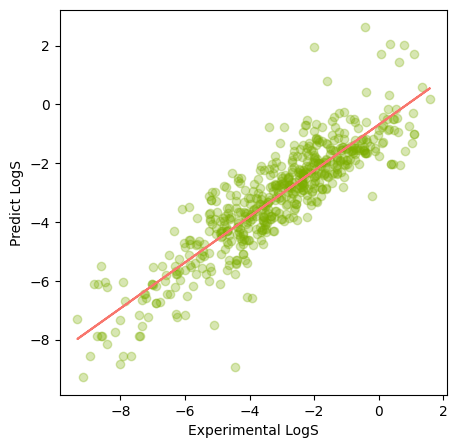

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(5,5))
plt.scatter(x=y_train, y=y_lr_train_pred, c="#7CAE00" ,alpha=0.3)

z = np.polyfit(y_train, y_lr_train_pred, 1)
p = np.poly1d(z)

plt.plot(y_train, p(y_train), '#F8766D')
plt.ylabel('Predict LogS')
plt.xlabel('Experimental LogS')